This is where I experiment with features.

In [ ]:
%load_ext line_profiler

In [198]:
from src.script import learning, load_object, MultilayerPerceptron, cost, accuracy, cost_gradient
from src.dataset_reader import load_dataset
import numpy as np
import matplotlib.pyplot as plt
import random
multilayer_perceptron = MultilayerPerceptron(layout=[784, 16, 16, 10], dtype=np.float64)
training_set, test_set = load_dataset(training_size=60000, old_format=True)
training_costs, accuracies, gradients_norms, consecutive_gradients_cosines = [], [], [], []

In [205]:
tracked_metrics = learning(multilayer_perceptron=multilayer_perceptron, training_set=training_set, test_set=test_set, eta=1.5*1e-03, steps_number=300, metrics_to_track=["training_costs", "accuracies", "gradients_norms", "consecutive_gradients_cosines"])
training_costs += tracked_metrics["training_costs"]
accuracies += tracked_metrics["accuracies"]
gradients_norms += tracked_metrics["gradients_norms"]
consecutive_gradients_cosines += tracked_metrics["consecutive_gradients_cosines"]

100%|██████████| 300/300 [15:59<00:00,  3.20s/it]


In [153]:
training_costs

[3.9483012833226185,
 1.5396329361218355,
 0.9846212543803995,
 0.9615456553499905,
 0.959768153027946,
 0.9548612050405898,
 0.9540748152819862,
 0.9426766232730215,
 0.932177507878641,
 0.9410267762892283,
 0.9276747708914923,
 0.9209649627390735,
 0.9228167736300433,
 0.9179470424823994,
 0.9111636066517642,
 0.9031710534396277,
 0.8990179216603633,
 0.9066859613344314,
 0.9039595754182971,
 0.8915029009536094,
 0.8937628899118104,
 0.8887572997703994,
 0.872581808957845,
 0.8704504774298679,
 0.8768803107180445,
 0.8809888004309689,
 0.8644105637321491,
 0.8600989293137455,
 0.865338634303405,
 0.857728411322315,
 0.86625641931589,
 0.8529462092095637,
 0.8384213539063553,
 0.8484905319731771,
 0.8372056424040653,
 0.8125826735282683,
 0.8340728814488482,
 0.828648720247036,
 0.8422173732409513,
 0.8405089698268341,
 0.8289201464453136,
 0.8059161346366234,
 0.8205091477354464,
 0.8204758756213564,
 0.7828549635164532,
 0.8010991175805456,
 0.7873907551652831,
 0.7931815826607103,


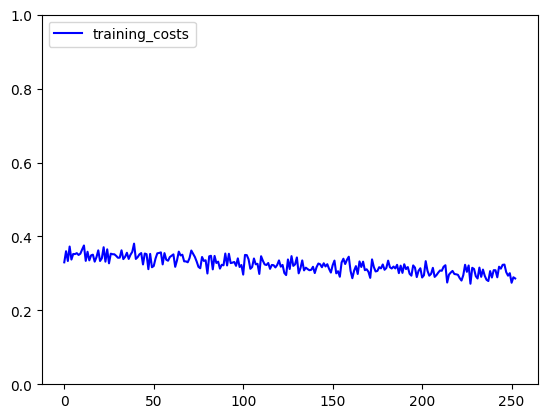

In [210]:
plt.close()
fig, ax1 = plt.subplots()

ax1.plot(training_costs[300:], label="training_costs", color="blue")
ax1.legend(loc = "upper left")
ax1.set_ylim([0,1])
"""
ax2 = ax1.twinx()
ax2.plot(consecutive_gradients_cosines[0:], label="previous_cosines", color="red")
ax2.legend(loc="upper right")
ax2.set_ylim([-1,1])

ax3 = ax2.twinx()
ax3.plot(gradients_norms[0:], label="previous_gradients_norms", color="purple")
ax3.legend(loc = "lower left")"""

plt.show()

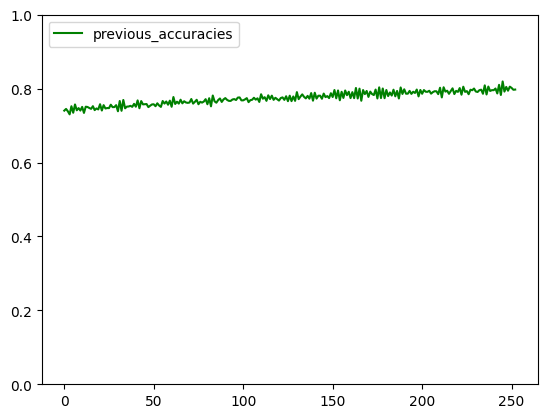

In [208]:
fig, ax1 = plt.subplots()

ax1.plot(accuracies[300:], label="previous_accuracies", color="green")
ax1.legend(loc = "upper left")
ax1.set_ylim([0,1])
"""
ax2 = ax1.twinx()
ax2.plot(previous_cosines[0:], label="previous_cosines", color="red")
ax2.legend(loc="upper right")
ax2.set_ylim([-1,1])

ax3 = ax1.twinx()
ax3.plot(previous_gradient_norms[3:], label="previous_gradient_norms", color="purple")
ax3.legend(loc = "lower left")"""

plt.show()

## 1st experiment : Are training_cost and accuracy smooth at the scales uf the current prefered learning step (eta = 8*1e-03) ?##

In [ ]:
print(cost(multilayer_perceptron=multilayer_perceptron, training_set=training_set))
print(accuracy(multilayer_perceptron=multilayer_perceptron, test_set=test_set))

In [148]:
in_between_costs = []
in_between_accuracies = []
eta = 1.3 * 1e-03
_training_set = random.choices(population=training_set, k=1000)
_cost_gradient = cost_gradient(
        multilayer_perceptron=multilayer_perceptron, training_set=_training_set
    )
N = len(multilayer_perceptron.layers)
layout = multilayer_perceptron.layout
nb_in_between_stops = 10
nudge = 1 / nb_in_between_stops

for _ in range(nb_in_between_stops+1):
    # modif. of the parameters
    for i in range(N):
        for variable in range(2):
            multilayer_perceptron.variables[i][variable] += (
                - nudge * eta * np.average(layout) * _cost_gradient[i][variable]
            )
            
    training_cost = cost(multilayer_perceptron=multilayer_perceptron, training_set=_training_set)
    in_between_costs.append(training_cost)
    _accuracy = accuracy(multilayer_perceptron=multilayer_perceptron, test_set=test_set)
    in_between_accuracies.append(_accuracy)

training_costs.append(in_between_costs[-1])
accuracies.append(in_between_accuracies[-1])
    

[]

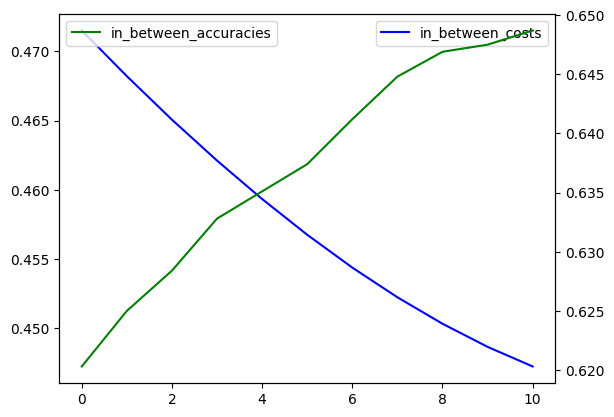

In [149]:
fig1, ax1 = plt.subplots()

ax1.plot(in_between_costs, label="in_between_costs", color="blue")
ax1.legend(loc="upper right")
#ax1.set_ylim([0.4,0.6])

ax2 = ax1.twinx()
ax2.plot(in_between_accuracies, label="in_between_accuracies", color="green")
ax2.legend(loc="upper left")
#ax2.set_ylim([0.6,0.7])

plt.plot()

In [194]:
multilayer_perceptron.variables

[[array([[nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
          nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
          nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
          nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
          nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
          nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
          nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
          nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
          nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
          nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
          nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
          nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
          nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
          nan, nan, nan, 